# IMDB Top 1000 Movies – Exploratory Data Analysis

## Objective
The goal of this project is to explore the IMDB Top 1000 movies dataset and identify patterns in movie ratings, genres, runtime, revenue, and audience engagement.

## Dataset
The dataset contains information about the top 1000 movies on IMDB including:
- Movie title
- Release year
- Genre
- Runtime
- IMDB rating
- Meta score
- Director
- Cast
- Number of votes
- Gross revenue

## Tools Used
- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Plotly

## Analysis Focus
This analysis aims to answer questions such as:
- Which genres dominate highly rated movies?
- Do longer movies receive higher ratings?
- Which movies generated the highest revenue?
- Do popular movies receive more votes?
- Which directors frequently appear in top movies?

# IMDB Top 1000 Movies – Exploratory Data Analysis 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='white')             ## Set a style for seaborn


import plotly
import plotly.graph_objects as go
import plotly.express as px

from plotly.subplots import make_subplots
import plotly.figure_factory as ff

from plotly.offline import plot,iplot,init_notebook_mode
init_notebook_mode(connected =True)

In [32]:
imdb = pd.read_csv("D:\Data Science\Assignment\imdb_top_1000.csv")

In [33]:
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [34]:
imdb.tail()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN
999,https://m.media-amazon.com/images/M/MV5BMTY5OD...,The 39 Steps,1935,NaN,86 min,"Crime, Mystery, Thriller",7.6,A man in London tries to help a counter-espion...,93.0,Alfred Hitchcock,Robert Donat,Madeleine Carroll,Lucie Mannheim,Godfrey Tearle,51853,NaN


In [35]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [36]:
imdb.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [10]:
import missingno as mno

<Axes: >

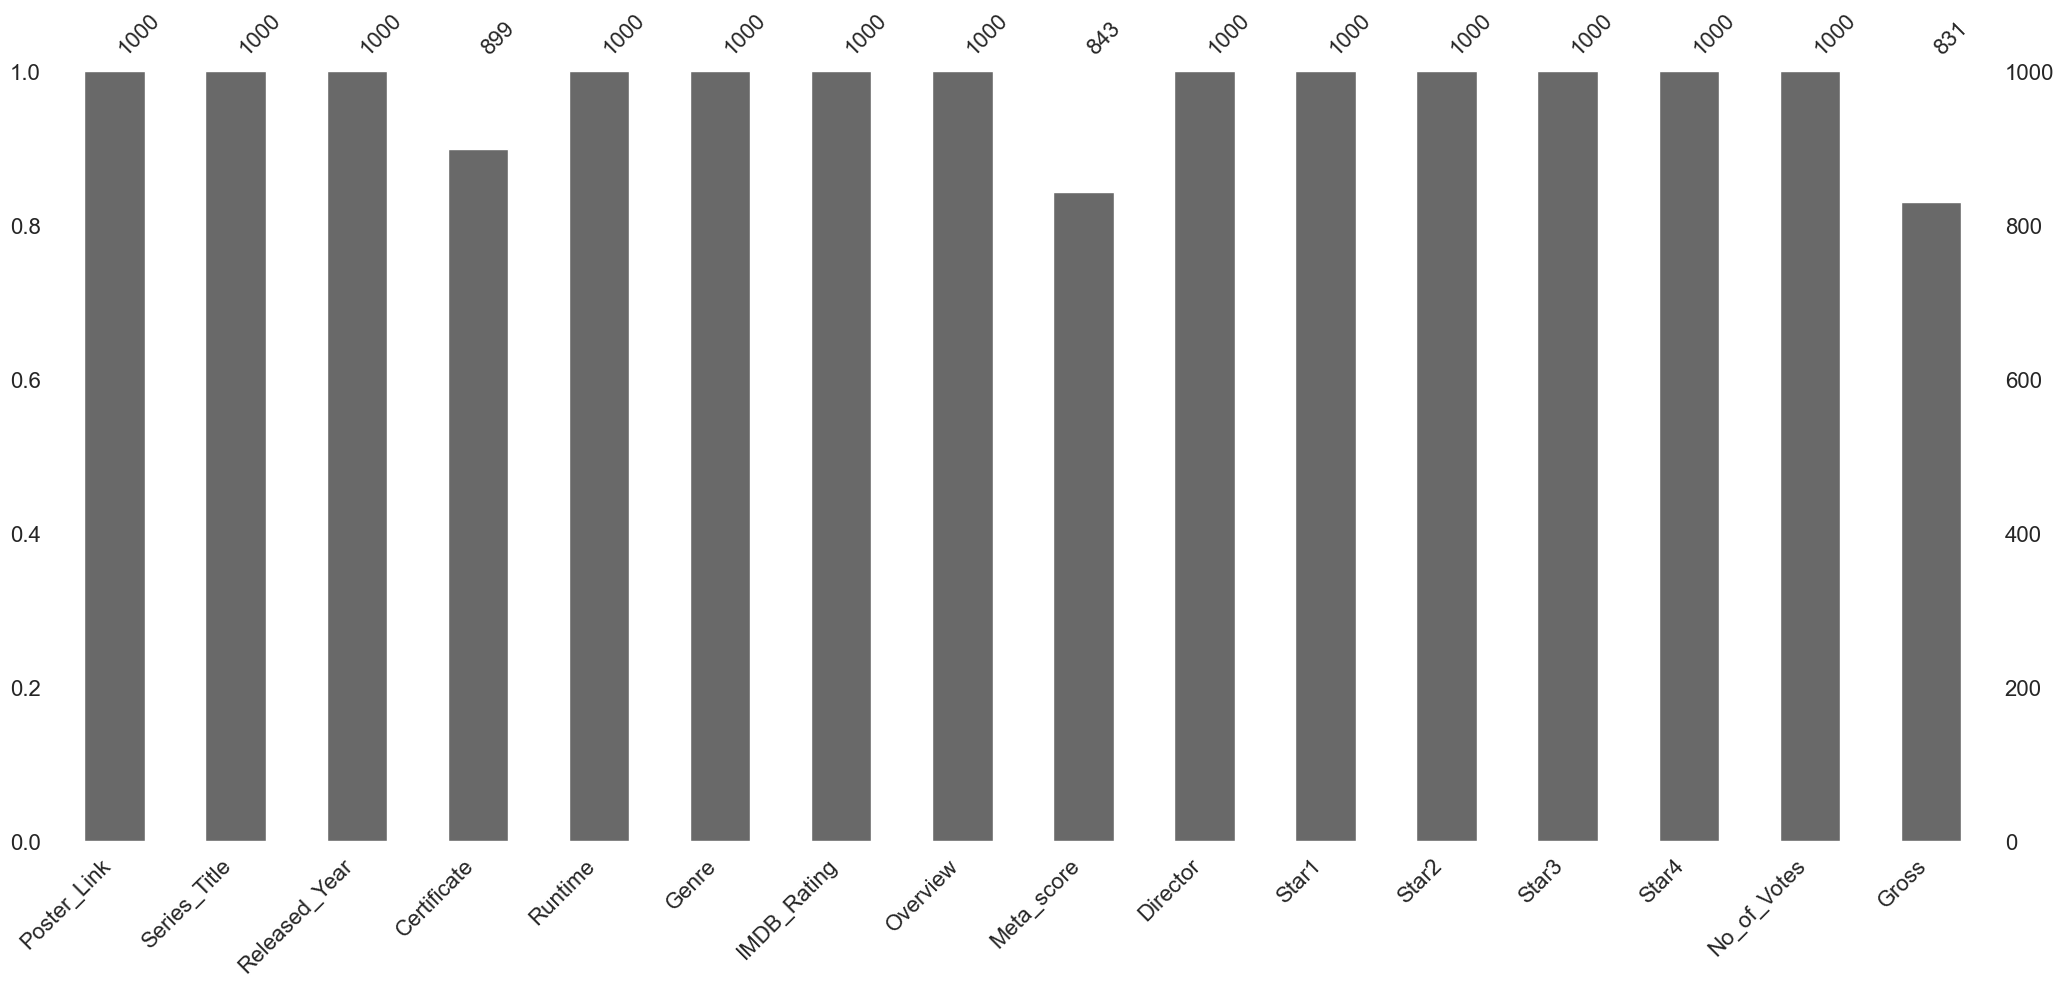

In [11]:
mno.bar(imdb)

In [40]:

imdb.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

---
              Only a few records have missing meta scores.
         The dataset is largely clean and suitable for analysis.
---

##  heatmap()

<Axes: >

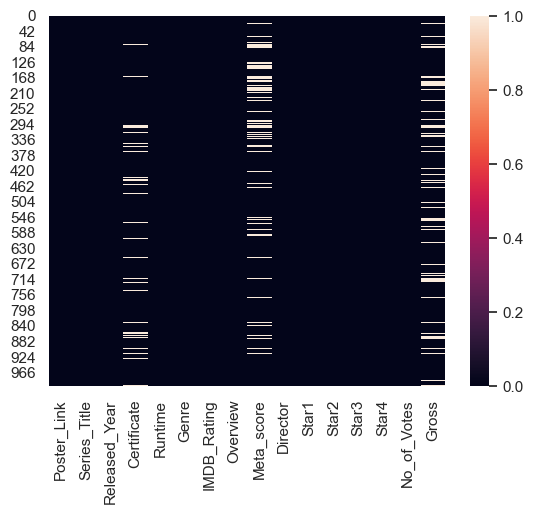

In [13]:
sns.heatmap(imdb.isnull())

## Changing DataType

In [14]:
imdb['Gross'] = imdb['Gross'].str.replace(',', '').astype('float')
imdb['Runtime'] =imdb['Runtime'].apply(lambda text: text.split()[0]).astype('int')

## filling missing value with .replace

In [15]:
imdb['Certificate'] = imdb['Certificate'].replace(np.nan,'unknown')               ##  Replacing Certification is much more difficuly so,give it as "Unknown"

imdb['Meta_score'] =  imdb['Meta_score'].replace(np.nan,np.mean(imdb['Meta_score']) )       ## Is more important So,fillup with Mean values

imdb['Gross'] = imdb['Gross'].replace(np.nan,np.mean(imdb['Gross']))           ##  Its also filling with Gross value

#    Data Visualisation 

## IMDB movies were released across different years

### Question

              How are the IMDB Top 1000 movies distributed across different release years?

In [16]:
imdb['Released_Year'] = pd.to_numeric(imdb['Released_Year'] ,errors='coerce')             ## Convert the year column to numeric.

In [17]:
fig =px.histogram(data_frame=imdb.sort_values(by= 'Released_Year'),x='Released_Year',nbins=30,color_discrete_sequence=['gold'])
fig.update_layout(font =dict(family='Lato',size=28,color='white'),title =dict(text='Distribution of IMDB Movies from 1920 - now',font=dict(size=30),x=.5),paper_bgcolor='black',plot_bgcolor='black',
                  xaxis =dict(title= 'Year of Release'),yaxis=dict(showgrid= False))

### insight 

          Most of the IMDB Top 1000 movies were released after the year 1990.
          This indicates that modern cinema dominates the list of highly rated movies.
          However, several classic films from earlier decades are still present.

## Genre

### Question

             Which genres appear most frequently among the IMDB Top 1000 movies?

In [18]:
imdb['Genre'].unique()

array(['Drama', 'Crime, Drama', 'Action, Crime, Drama',
       'Action, Adventure, Drama', 'Biography, Drama, History',
       'Action, Adventure, Sci-Fi', 'Drama, Romance', 'Western',
       'Action, Sci-Fi', 'Biography, Crime, Drama',
       'Action, Adventure, Fantasy', 'Comedy, Drama, Thriller',
       'Adventure, Drama, Sci-Fi', 'Animation, Adventure, Family',
       'Drama, War', 'Crime, Drama, Fantasy', 'Comedy, Drama, Romance',
       'Crime, Drama, Mystery', 'Crime, Drama, Thriller',
       'Action, Drama, Mystery', 'Drama, Family, Fantasy', 'Drama, Music',
       'Biography, Comedy, Drama', 'Drama, Mystery, Sci-Fi',
       'Biography, Drama, Music', 'Crime, Mystery, Thriller',
       'Animation, Adventure, Drama', 'Animation, Drama, War',
       'Adventure, Comedy, Sci-Fi', 'Horror, Mystery, Thriller',
       'Drama, Romance, War', 'Comedy, Drama, Family',
       'Animation, Drama, Fantasy', 'Action, Biography, Drama',
       'Animation, Action, Adventure', 'Drama, Western',


---
     There is Lots of genres are there like 'Action,Drama,Comedy' ,'Action, Adventure, Famil' ...etc we re considering the first genre only 
---

####  Primary Genre Extraction and Distribution

In [22]:
imdb['genre'] = imdb['Genre'].apply(lambda text: text.split(',')[0])
imdb.drop(columns='Genre', inplace=True)
imdb['genre'].value_counts()

genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64

### Barplot

In [25]:
def bar_plot(column, df=imdb, mode="value_counts", by=None, limit=5):
    
    # Prepare data
    if mode == "value_counts":
        data = df[column].value_counts().head(limit)
        x = data.index
        y = data.values
        title = column

    elif mode == "sort":
        data = df.sort_values(by=by, ascending=False).head(limit)
        x = data[column]
        y = data[by]
        title = by

    else:
        raise ValueError("mode must be 'value_counts' or 'sort'")

    # Create plot
    
    fig = px.bar(x=y, y=x, orientation="h", color_discrete_sequence=["gold"])

    # Styling
    fig.update_layout(
        title=f"IMDB Movies - {title}",
        font=dict(family="Lato", size=18, color="white"),paper_bgcolor="black",plot_bgcolor="black",xaxis=dict(title=title, showgrid=False),
        yaxis=dict(title=column, showgrid=False)
        
    )

    fig.show()

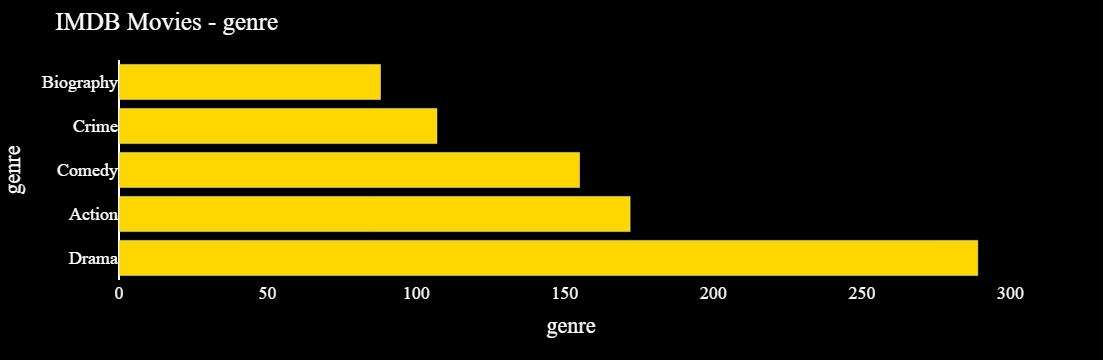

In [26]:
bar_plot('genre',limit=5)

### Insight
            Drama is the most dominant genre among the top movies.
            This suggests that emotionally driven storytelling tends to receive higher critical recognition.
            Action and Comedy are also common but appear less frequently than Drama.

## Plot: Genre vs Gross Revenue

### Question

             Which movie genres generate the highest total box office revenue?

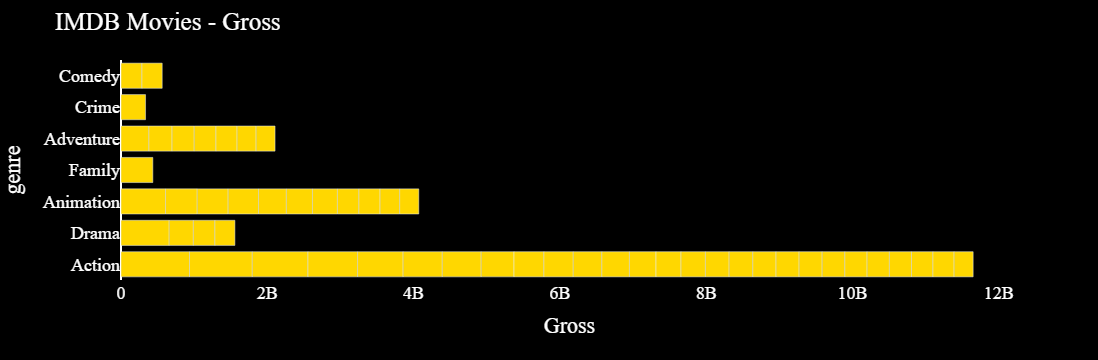

In [164]:
bar_plot('genre', limit=53, mode='sort', by="Gross")

In [73]:
## By the collection gross Action hits different Impact

### Insight
             Action movies generate the highest total revenue among the genres.
             This indicates that action films tend to attract larger audiences and higher box office collections.
             While Drama dominates in count, Action dominates in revenue.

## KDE plot

### Question
           How does movie runtime vary across different genres?

In [43]:
def add_mean_line(data, var='Runtime', **kwargs):
    
    if not var:
        return
    
    mean = data[var].mean()

    # current axis
    ax = plt.gca()

    # Adding vertical line at mean
    ax.axvline(mean, color='red', lw=3, ls='-.', alpha=0.7)

    # Annotation position
    x_pos = 0.75
    fontsize = 12

    if mean < 120:
        x_pos = 0.65

    ax.text(
        x_pos, 0.7,f"Mean: {mean:.1f}",transform=ax.transAxes,color='red',fontweight='bold',fontsize=fontsize)

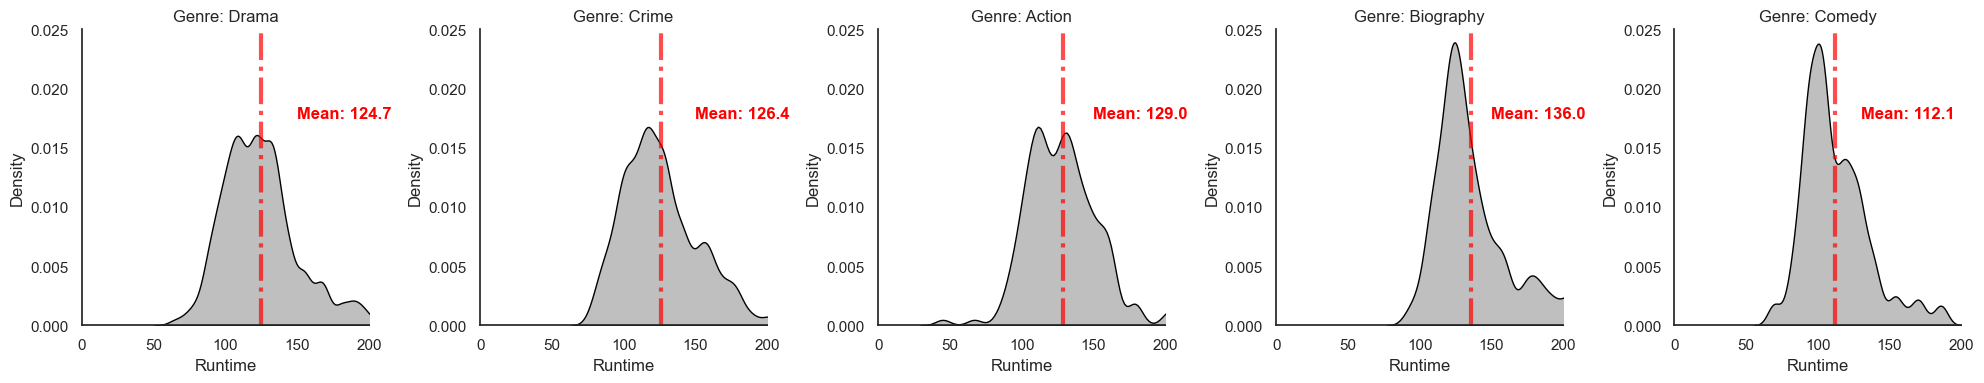

In [44]:
# Create a FacetGrid for selected genres
g = sns.FacetGrid(
    
    # Filter dataset for specific genres
    imdb[imdb['genre'].isin(['Drama','Crime','Action','Comedy','Biography'])],

    # Create separate plot for each genre
    col='genre',

    # Height of each subplot
    height=4,

    # Allow different x-axis ranges for each subplot
    sharex=False,

    # Allow different y-axis ranges for each subplot
    sharey=False,

    # Set runtime range
    xlim=(0,200),

    # Set density range
    ylim=(0,0.025)
)


# Draw KDE distribution curve for Runtime
g.map(
    sns.kdeplot,'Runtime',fill=True,color='black',bw_adjust=0.5
)


# Add mean runtime line to each subplot
g.map_dataframe(add_mean_line)


# Set titles for each subplot
g.set_titles(col_template='Genre: {col_name}')


# Display the plot
plt.show()

## Scatter plot

### Question

            Do movies with higher revenue receive more audience votes?

In [46]:
fig = px.scatter(imdb,x="Gross",y='No_of_Votes',hover_data=['Series_Title'],color='genre')
fig.update_layout(font =dict(family='Lato',size=18,color='white'),title =dict(text=f'IMDB Movies - Scatter Plot',font=dict(size=30),x=.5),paper_bgcolor='black',plot_bgcolor='black',
                  xaxis =dict(title= 'Gross',showgrid=False),yaxis=dict(title="No_of_Votes",showgrid= False))


### Insight
            Movies with higher box office revenue tend to receive more votes,
            suggesting that commercially successful movies often attract larger audiences.
            However, there are also movies with moderate revenue that receive high votes,
            indicating strong audience appreciation.

## Top Grossing Movies

### Question
           Which movies generated the highest box office revenue?

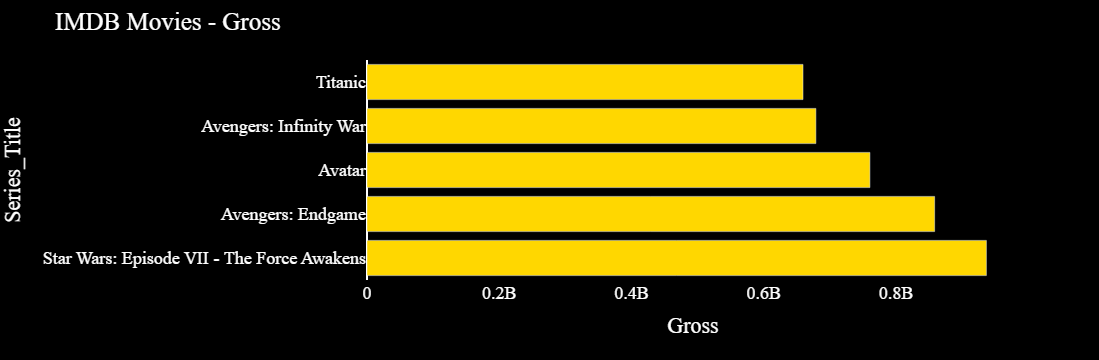

In [175]:
bar_plot("Series_Title",mode='sort',by="Gross",limit=5)

### Insight
                     Movies like Avatar, Avengers: Endgame, and Star Wars: The Force Awakens
                     appear among the highest grossing movies.
                     These films belong mainly to the action and science fiction genres,
                     which are known for large-scale productions and global popularity.

## Runtime

### Question
             Which movies have the longest runtime in the dataset?

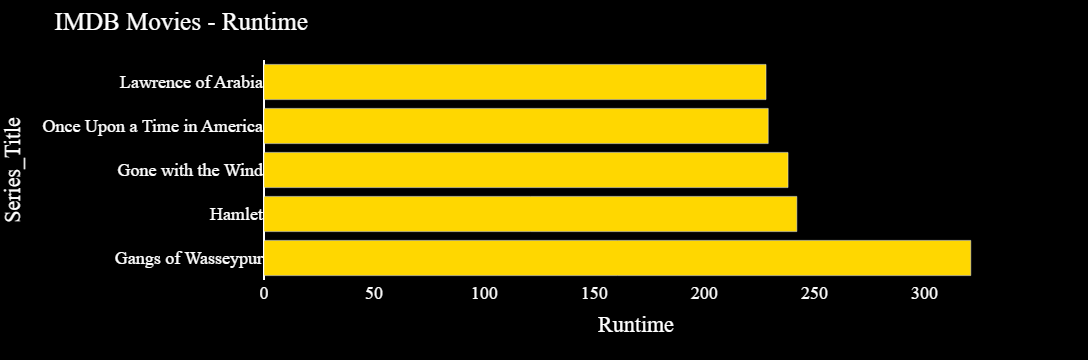

In [166]:
bar_plot('Series_Title',mode='sort',by='Runtime')

###  insight
             Movies such as Gangs of Wasseypur and Lawrence of Arabia
             have significantly longer runtimes compared to typical films.
             However, longer runtime does not necessarily guarantee higher ratings.

## IMDB Rating

### Question
             Which movies have the highest IMDB ratings?

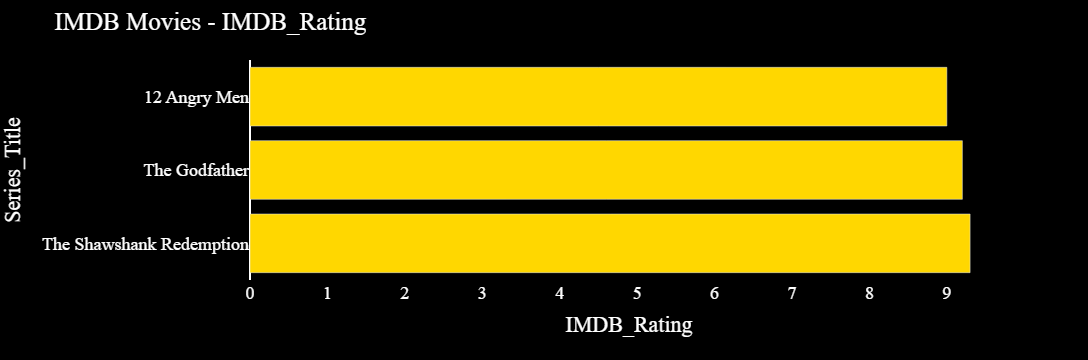

In [167]:
bar_plot('Series_Title',mode='sort',by='IMDB_Rating',limit=3)

### Insights
             The Shawshank Redemption, The Godfather, and 12 Angry Men
             are among the highest rated movies in the dataset.
             These films are widely recognized as cinematic classics.

## Certificate Distributions
### Question
              Which movie certification categories are most common in the dataset?

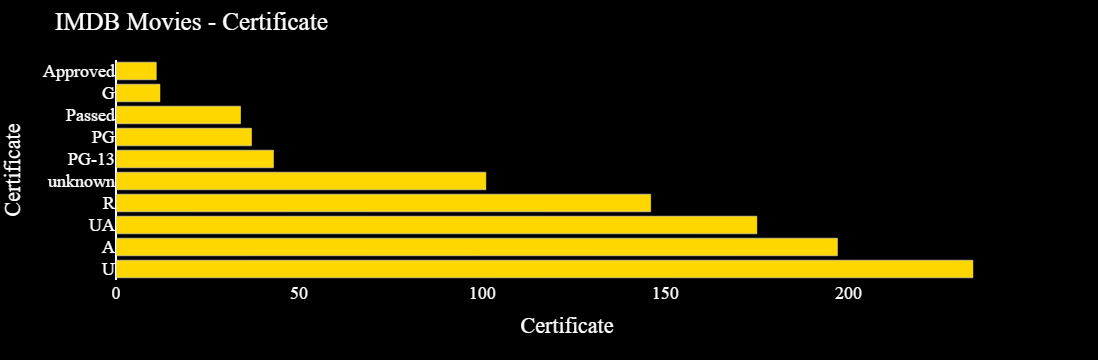

In [168]:
bar_plot('Certificate',limit=10)

### Insights
                   The majority of movies fall under the 'U','A','UA', and 'R' certification categories.
                    This suggests that most top movies are suitable for broad audiences.

## Director
### Question

            Which directors appear most frequently in the IMDB Top 1000 list?

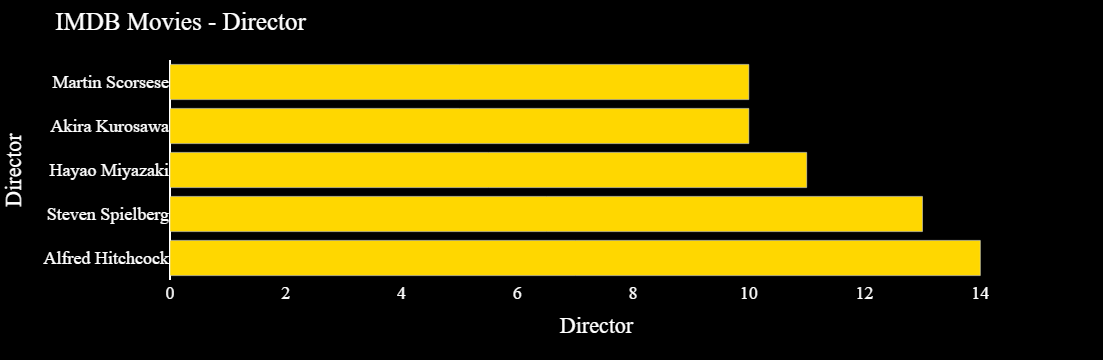

In [170]:
bar_plot('Director',limit=5)

### Insights
                Directors such as Alfred Hitchcock and Steven Spielberg appear multiple times,
                indicating their consistent contribution to highly rated movies.

### Top-Voted

In [27]:
Top_voted = imdb.sort_values(['No_of_Votes'],ascending =False)

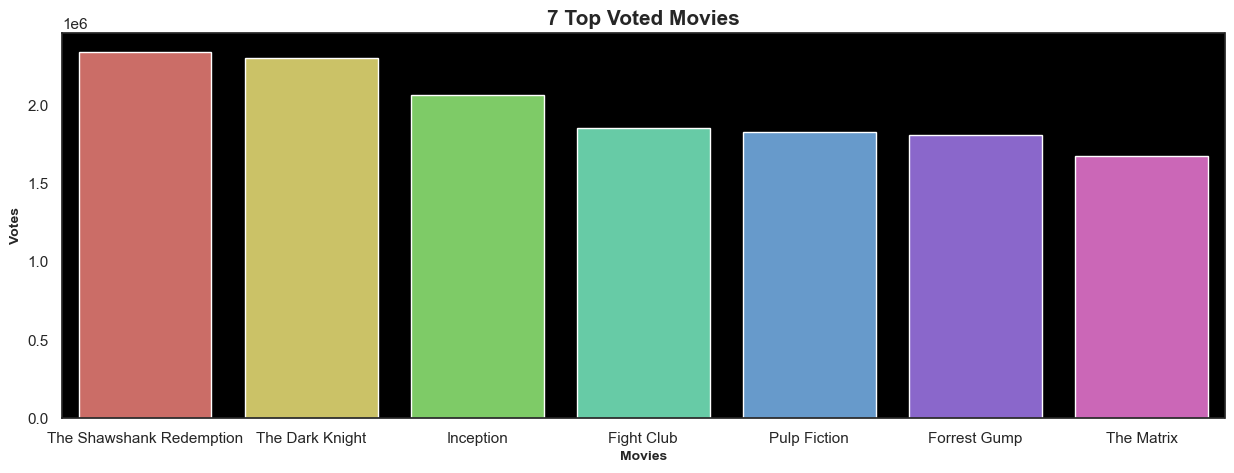

In [29]:
fig,ax = plt.subplots(figsize=(15,5))
ax.set(facecolor="Black")
sns.barplot(x=Top_voted["Series_Title"][:7],y=Top_voted['No_of_Votes'][:7],hue=Top_voted["Series_Title"][:7], palette='hls',legend=False)

plt.title('7 Top Voted Movies', fontweight='bold',fontsize=15)
plt.xlabel('Movies',fontsize=10,fontweight='bold')
plt.ylabel('Votes', fontsize=10,fontweight='bold')
plt.show()

In [109]:
Top_gross = imdb.sort_values(['Gross'],ascending=False)

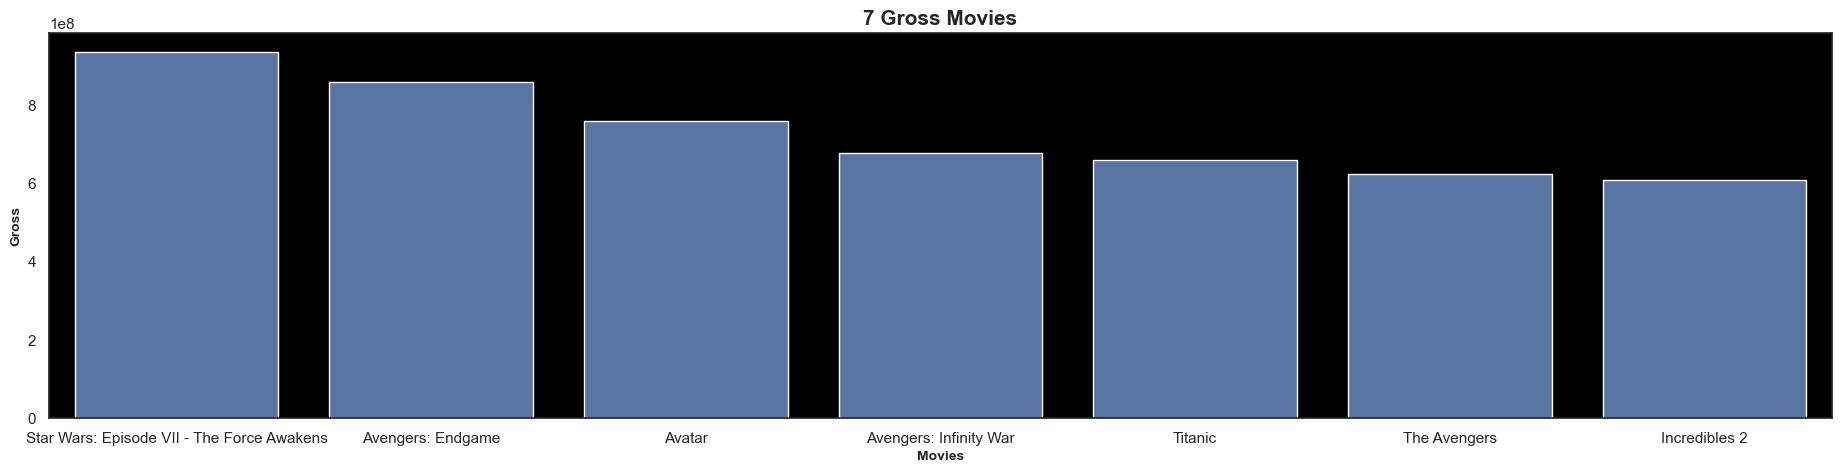

In [174]:
fig,ax = plt.subplots(figsize=(23,5))
ax.set(facecolor="Black")
sns.barplot(x=Top_gross["Series_Title"][:7],y=Top_gross['Gross'][:7], palette=None)

plt.title('7 Gross Movies', fontweight='bold',fontsize=15)
plt.xlabel('Movies',fontsize=10,fontweight='bold')
plt.ylabel('Gross', fontsize=10,fontweight='bold')
plt.show()

## 1. Relationships

### Question
            Does movie runtime influence IMDB rating?

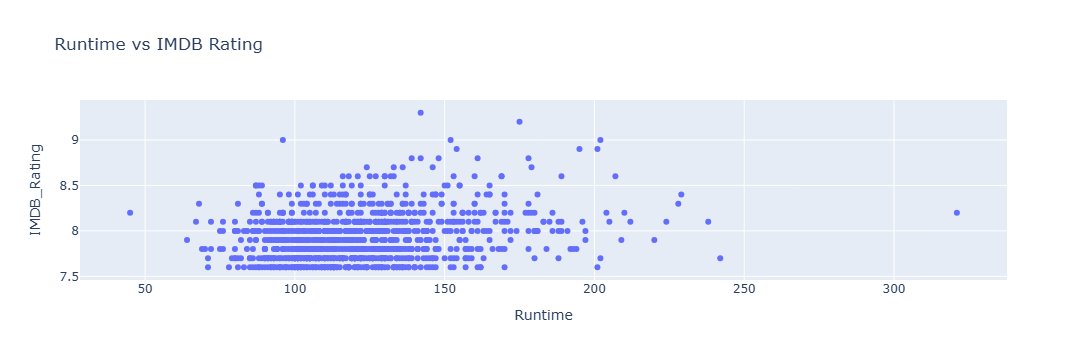

In [49]:
fig = px.scatter(imdb, x="Runtime", y="IMDB_Rating",
                 title="Runtime vs IMDB Rating")
fig.show()

### Insights
            There is no strong relationship between runtime and IMDB rating.
            Highly rated movies appear across a wide range of runtimes.

## 2.Comparisons


### Question
              Which genres have the highest average IMDB ratings?

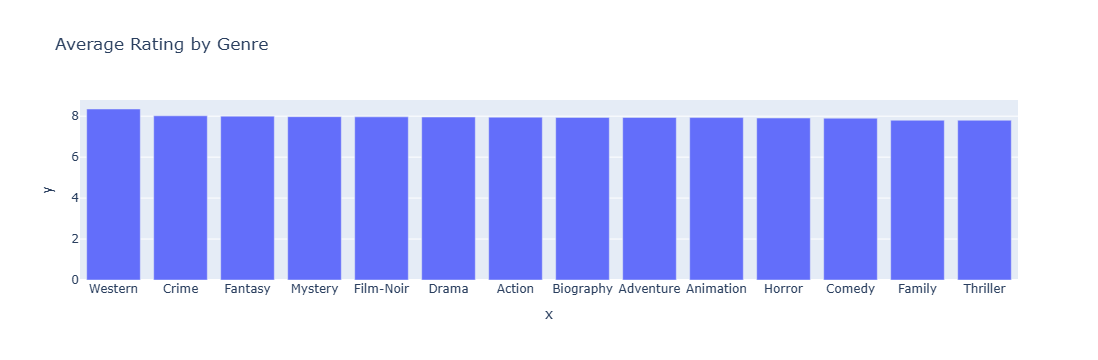

In [56]:
genre_rating = imdb.groupby("genre")["IMDB_Rating"].mean().sort_values(ascending=False)


fig = px.bar(x=genre_rating.index, y=genre_rating.values,
             title="Average Rating by Genre")

fig.show()

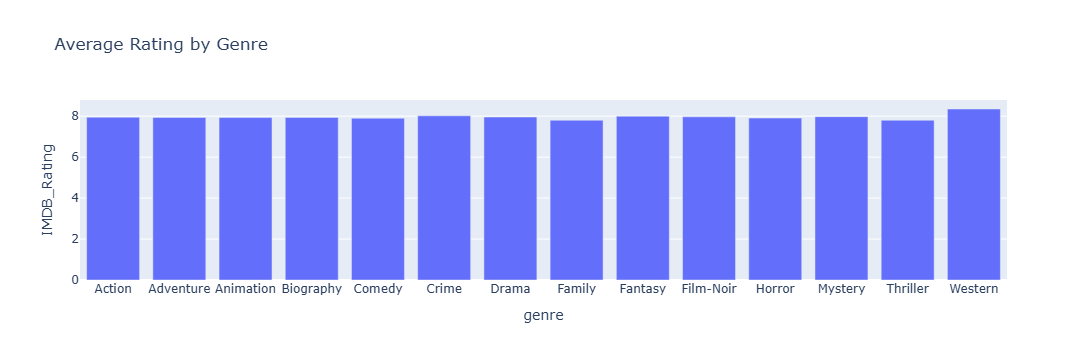

In [57]:
genre_rating = imdb.groupby("genre")["IMDB_Rating"].mean().reset_index()

fig = px.bar(genre_rating, x="genre", y="IMDB_Rating",
             title="Average Rating by Genre")

fig.show()

### Insights
            Genres such as Western,Crime ,and Fantasy tend to have slightly higher average ratings,
            though the differences between genres are relatively small.

## Correlation Analysis

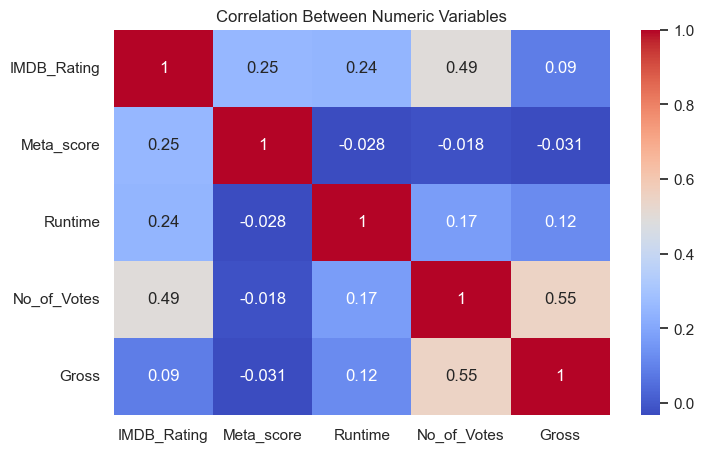

In [30]:
numeric = imdb[['IMDB_Rating','Meta_score','Runtime','No_of_Votes','Gross']]
plt.figure(figsize=(8,5))
sns.heatmap(numeric.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Between Numeric Variables")
plt.show()

### insights
            Movies with higher gross revenue tend to receive more votes.
            Runtime shows weak correlation with ratings.

# Key Insights

1. Drama is the most dominant genre among the IMDB Top 1000 movies.
2. Action movies generate the highest box office revenue.
3. Most movies have runtimes between 100–140 minutes.
4. IMDB ratings mostly fall between 7.5 and 8.5.
5. Movies with higher revenue tend to receive more audience votes.
6. Certain directors such as Christopher Nolan and Steven Spielberg appear frequently.

# Conclusion

This exploratory analysis reveals interesting patterns in highly rated movies. 
While drama dominates in number of films, action movies tend to generate the highest revenue. 
Most successful movies maintain runtimes around two hours and receive ratings between 7.5 and 8.5. 
The analysis also suggests that commercially successful movies tend to attract larger audiences in terms of votes.